In [2]:
import numpy as np

In [58]:
def jacobi(A: np.ndarray, b: np.ndarray, x0: np.ndarray, x_tr: np.ndarray, max_iter, tol):
    errors = []
    x = x0.copy()

    D = np.diag(A)
    R = A - np.diagflat(D)

    if np.any(D == 0):
        print("Диагональный элемент равен нулю")
        return x, errors

    for _ in range(max_iter):
        x_new = (b - R @ x) / D
        diff = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(np.linalg.norm(x_new - x_tr, ord=np.inf))

        if diff < tol:
            print(f"Якоби: сошелся за {_+1} итераций.")
            return x_new, errors

        x = x_new

    print("Максимальное количество итераций достигнуто")
    return x, errors

In [ ]:
A = np.array([[-1, 1, -1],
              [-1, 4, -2],
              [2, -3, 5]], dtype=float)

x_tr = np.array([1, 2, 3], dtype=float)
b = np.array([1, 2, 3])

x0 = np.array([0, 0, 0], dtype=float)

solution, convergence_errors = jacobi(A, b, x0, x_tr, tol=1e-8, max_iter=500)
solution

Максимальное количество итераций достигнуто


array([ 2.40154612e+24, -1.20077306e+24,  1.49667346e+24])

In [7]:
import matplotlib.pyplot as plt

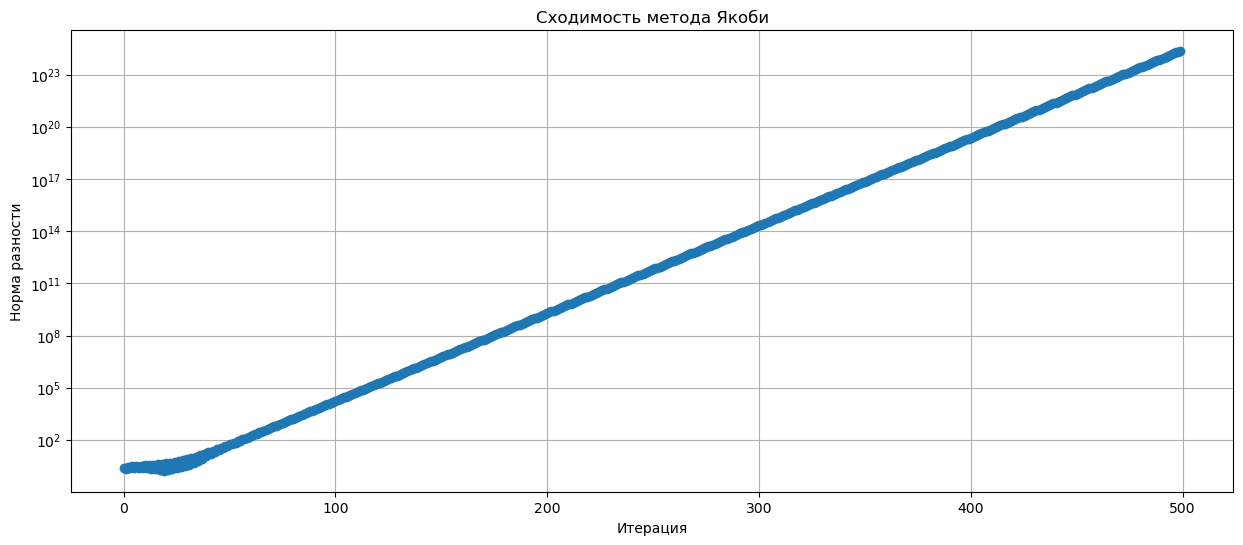

In [64]:
# График сходимости
plt.figure(figsize=(15,6))
plt.semilogy(convergence_errors, marker='o')
plt.xlabel("Итерация")
plt.ylabel("Норма разности")
plt.title("Сходимость метода Якоби")
plt.grid(True)
plt.show()